In [1]:
# ============================================
# LOCAL SPARK INIT
# ============================================

from pyspark.sql import SparkSession
import os

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = (
    SparkSession.builder
    .appName("IQR-Anomaly-Local")
    .master("local[1]")                 # 🔥 SINGLE THREAD
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.shuffle.service.enabled", "false")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
spark


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/06 13:44:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Robust repo root detection ---
HERE = Path().resolve()
REPO_ROOT = HERE
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "src" / "sdk" / "python").exists() and (REPO_ROOT / "amos_team_resources").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "amos_team_resources").exists():
    raise RuntimeError(f"Could not find repo root from: {HERE}")

SDK_PATH = REPO_ROOT / "src" / "sdk" / "python"
sys.path.insert(0, str(SDK_PATH))

from rtdip_sdk.pipelines.anomaly_detection.spark.iqr import (
    IqrAnomalyDetection,
    IqrAnomalyDetectionRollingWindow,
    DecompositionIqrAnomalyDetection,
)

print("Imports OK")
print("Repo root:", REPO_ROOT)
print("Shell parquet:", REPO_ROOT / "amos_team_resources" / "shell" / "data" / "ShellData.parquet")


Imports OK
Repo root: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting
Shell parquet: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting/amos_team_resources/shell/data/ShellData.parquet


In [3]:
data_path = REPO_ROOT / "amos_team_resources" / "shell" / "data" / "ShellData.parquet"

print("\n================================================================================")
print("SHELL DATA LOAD (SAFE MODE)")
print("================================================================================")
print("Loading from:", data_path)
print("Exists:", data_path.exists())

if not data_path.exists():
    raise FileNotFoundError(
        f"Shell parquet not found at: {data_path}\n"
        "Run: python amos_team_resources/shell/ingest/ingest_shell_data.py"
    )

# 1) Loading ONLY TagName to choose a sensor
df_tags = pd.read_parquet(data_path, columns=["TagName"], engine="pyarrow")
print("Total rows (TagName only):", f"{len(df_tags):,}")
print("Unique sensors:", f"{df_tags['TagName'].nunique():,}")


SENSOR_NAME = df_tags["TagName"].value_counts().idxmax()


print("Using sensor:", SENSOR_NAME)

# Free memory
del df_tags

# 2) Load ONLY the selected sensor (fast + safe)
df_sensor = pd.read_parquet(
    data_path,
    columns=["TagName", "EventTime", "Value"],
    filters=[("TagName", "==", SENSOR_NAME)],
    engine="pyarrow",
)

print("Sensor rows:", f"{len(df_sensor):,}")
print("Columns:", df_sensor.columns.tolist())
df_sensor.head()



SHELL DATA LOAD (SAFE MODE)
Loading from: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting/amos_team_resources/shell/data/ShellData.parquet
Exists: True
Total rows (TagName only): 214,991,102
Unique sensors: 7,759
Using sensor: T:4FU4PRBV3NO0V_0PLM40R-.34
Sensor rows: 553,540
Columns: ['TagName', 'EventTime', 'Value']


,TagName,EventTime,Value
0,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-07-13 22:49:13.330,3.35
1,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-07-13 20:46:18.211,3.57
2,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-07-13 20:25:33.366,3.25
3,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-07-13 07:27:48.512,3.59
4,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-07-13 06:50:43.537,3.12



PREPROCESSING (PANDAS)
Sensor: T:4FU4PRBV3NO0V_0PLM40R-.34
Initial rows: 553,540
Dropped rows (NaNs/bad parse): 0
Remaining rows: 553,540
Time range: 2024-06-28 00:00:03.215000+00:00 → 2024-07-27 23:59:57.573000+00:00
Value stats:
count    553540.000000
mean          3.498122
std           1.523823
min           0.000000
1%            2.230000
5%            2.550000
50%           3.510000
95%           4.360000
99%           4.680000
max         312.000000
Name: value, dtype: float64


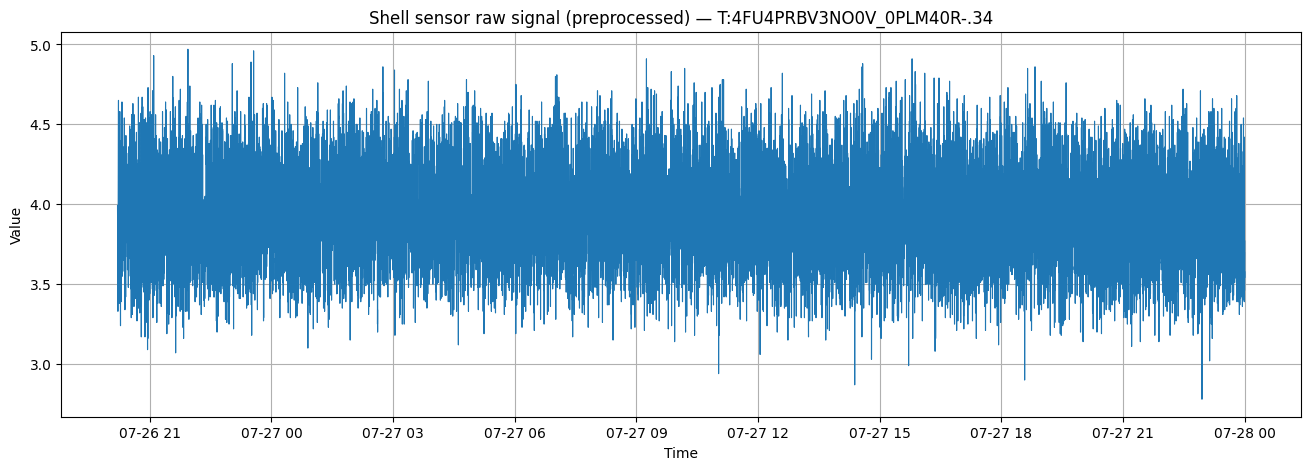

,TagName,timestamp,value
0,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-06-28 00:00:03.215000+00:00,4.04
1,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-06-28 00:00:33.276000+00:00,4.04
2,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-06-28 00:00:37.363000+00:00,3.71
3,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-06-28 00:00:43.401000+00:00,4.03
4,T:4FU4PRBV3NO0V_0PLM40R-.34,2024-06-28 00:00:48.315000+00:00,3.76


In [4]:
print("\n================================================================================")
print("PREPROCESSING (PANDAS)")
print("================================================================================")
print("Sensor:", SENSOR_NAME)
print("Initial rows:", f"{len(df_sensor):,}")

# Keep only what we need
df_sensor = df_sensor[["TagName", "EventTime", "Value"]].copy()

# Parse timestamp + numeric value
df_sensor["EventTime"] = pd.to_datetime(df_sensor["EventTime"], errors="coerce", utc=True)
df_sensor["Value"] = pd.to_numeric(df_sensor["Value"], errors="coerce")

# Drop invalid rows
before = len(df_sensor)
df_sensor = df_sensor.dropna(subset=["EventTime", "Value"])
after = len(df_sensor)

print("Dropped rows (NaNs/bad parse):", f"{before - after:,}")
print("Remaining rows:", f"{after:,}")

# Sort by time
df_sensor = df_sensor.sort_values("EventTime").reset_index(drop=True)

# Standardize names for downstream components
df_sensor = df_sensor.rename(columns={"EventTime": "timestamp", "Value": "value"})

# Basic stats
print("Time range:", df_sensor["timestamp"].min(), "→", df_sensor["timestamp"].max())
print("Value stats:")
print(df_sensor["value"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

# Quick sanity plot (small sample if huge)
PLOT_MAX = 20000
df_plot = df_sensor if len(df_sensor) <= PLOT_MAX else df_sensor.iloc[-PLOT_MAX:]

plt.figure(figsize=(16, 5))
plt.plot(df_plot["timestamp"], df_plot["value"], linewidth=0.8)
plt.title(f"Shell sensor raw signal (preprocessed) — {SENSOR_NAME}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

df_sensor.head()


In [5]:
print("\n================================================================================")
print("CONVERT TO SPARK DF")
print("================================================================================")

from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder.getOrCreate()

# Keep only the standardized columns (plus TagName if you want)
df_for_spark = df_sensor[["timestamp", "value"]].copy()

# (Optional) Make timestamp timezone-naive for Spark compatibility
# If your timestamps are timezone-aware (UTC), Spark sometimes gets picky.
df_for_spark["timestamp"] = pd.to_datetime(df_for_spark["timestamp"], errors="coerce").dt.tz_localize(None)

df_spark = spark.createDataFrame(df_for_spark)

print("Spark schema:")
df_spark.printSchema()

print("Spark sample:")
df_spark.show(5, truncate=False)

print("Row count (Spark):", df_spark.count())



CONVERT TO SPARK DF
Spark schema:
root
 |-- timestamp: timestamp (nullable = true)
 |-- value: double (nullable = true)

Spark sample:


Exception ignored in: <_io.BufferedWriter name=5>                   (0 + 1) / 1]
Traceback (most recent call last):
  File "/Users/starbook/.pyenv/versions/3.13.0/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 200, in manager
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

+-----------------------+---------+
|timestamp              |value    |
+-----------------------+---------+
|2024-06-28 00:00:03.215|4.04     |
|2024-06-28 00:00:33.276|4.04     |
|2024-06-28 00:00:37.363|3.7099998|
|2024-06-28 00:00:43.401|4.0299997|
|2024-06-28 00:00:48.315|3.76     |
+-----------------------+---------+
only showing top 5 rows
Row count (Spark): 553540



SANITY PLOT (timestamp/value)


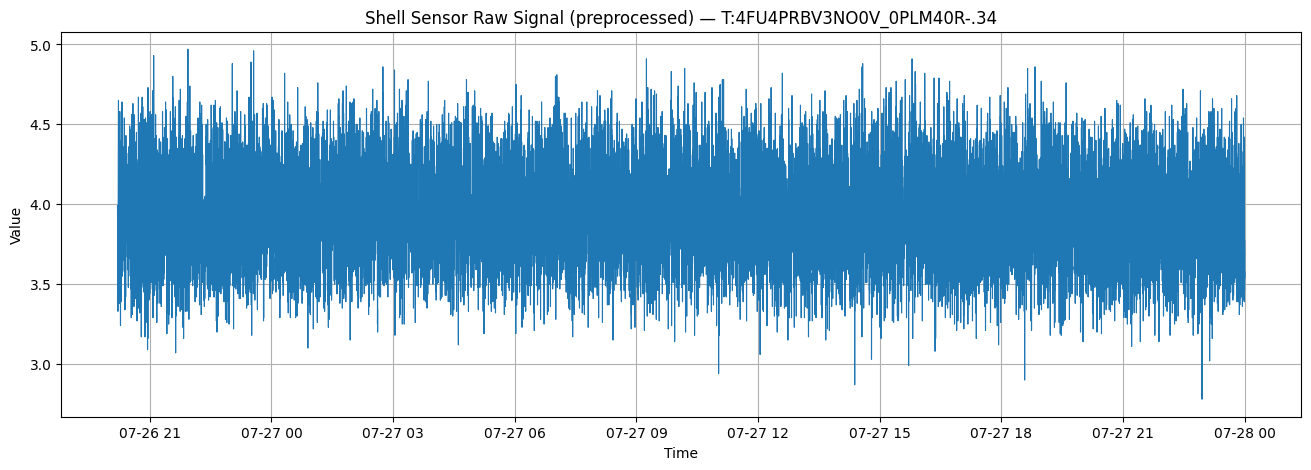

In [6]:
print("\n================================================================================")
print("SANITY PLOT (timestamp/value)")
print("================================================================================")

PLOT_MAX = 20000
df_plot = df_sensor if len(df_sensor) <= PLOT_MAX else df_sensor.iloc[-PLOT_MAX:]

plt.figure(figsize=(16, 5))
plt.plot(df_plot["timestamp"], df_plot["value"], linewidth=0.8)
plt.title(f"Shell Sensor Raw Signal (preprocessed) — {SENSOR_NAME}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()



IQR ANOMALY DETECTION — BASELINE (GLOBAL)
Result schema:
root
 |-- timestamp: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- q1: double (nullable = false)
 |-- q3: double (nullable = false)
 |-- iqr: double (nullable = false)
 |-- lower_bound: double (nullable = false)
 |-- upper_bound: double (nullable = false)
 |-- is_anomaly: boolean (nullable = true)

Result sample:
+-----------------------+---------+---------+---------+---+-----------+-----------------+----------+
|timestamp              |value    |q1       |q3       |iqr|lower_bound|upper_bound      |is_anomaly|
+-----------------------+---------+---------+---------+---+-----------+-----------------+----------+
|2024-06-28 00:00:03.215|4.04     |3.1299999|3.8899999|1.0|1.6299999  |5.389999899999999|false     |
|2024-06-28 00:00:33.276|4.04     |3.1299999|3.8899999|1.0|1.6299999  |5.389999899999999|false     |
|2024-06-28 00:00:37.363|3.7099998|3.1299999|3.8899999|1.0|1.6299999  |5.389999899999999|false    

Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/starbook/.pyenv/versions/3.13.0/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 200, in manager
BrokenPipeError: [Errno 32] Broken pipe


Rows in result: 553540
Anomalies: 120


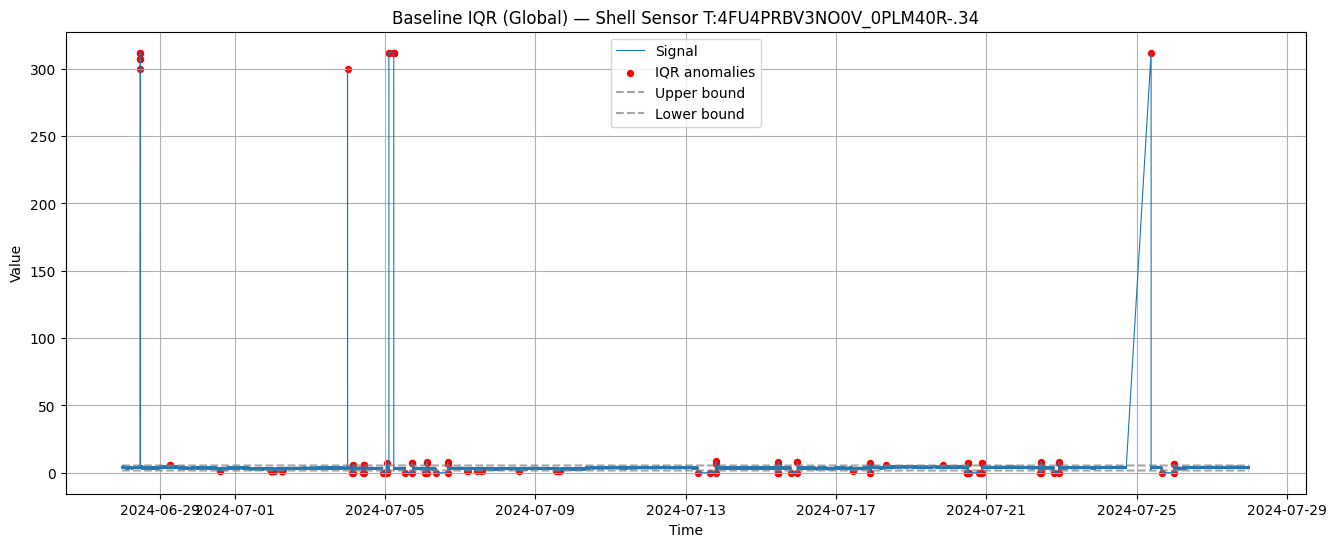

 Saved: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting/amos_team_resources/anomaly_detection/iqr/outputs/iqr_shell_raw.png


In [7]:
print("\n================================================================================")
print("IQR ANOMALY DETECTION — BASELINE (GLOBAL)")
print("================================================================================")

iqr_detector = IqrAnomalyDetection(
    time_column="timestamp",
    value_column="value",
    k=1.5,
    min_iqr=1.0,
    return_only_anomalies=False  # required for plotting bounds + signal
)

df_iqr = iqr_detector.detect(df_spark)

print("Result schema:")
df_iqr.printSchema()

print("Result sample:")
df_iqr.show(5, truncate=False)

pdf_iqr = df_iqr.toPandas()
print("Rows in result:", len(pdf_iqr))
print("Anomalies:", int(pdf_iqr["is_anomaly"].sum()))

plt.figure(figsize=(16, 6))
plt.plot(pdf_iqr["timestamp"], pdf_iqr["value"], label="Signal", linewidth=0.8)

plt.scatter(
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "timestamp"],
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "value"],
    color="red",
    label="IQR anomalies",
    s=18
)

plt.plot(pdf_iqr["timestamp"], pdf_iqr["upper_bound"], linestyle="--", color="gray", alpha=0.7, label="Upper bound")
plt.plot(pdf_iqr["timestamp"], pdf_iqr["lower_bound"], linestyle="--", color="gray", alpha=0.7, label="Lower bound")

plt.title(f"Baseline IQR (Global) — Shell Sensor {SENSOR_NAME}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

out_path = REPO_ROOT / "amos_team_resources" / "anomaly_detection" / "iqr" / "outputs"
out_path.mkdir(parents=True, exist_ok=True)

plt.savefig(out_path / "iqr_shell_raw.png", dpi=150, bbox_inches="tight")
plt.show()

print(" Saved:", out_path / "iqr_shell_raw.png")



BASELINE IQR — ZOOMED VIEW


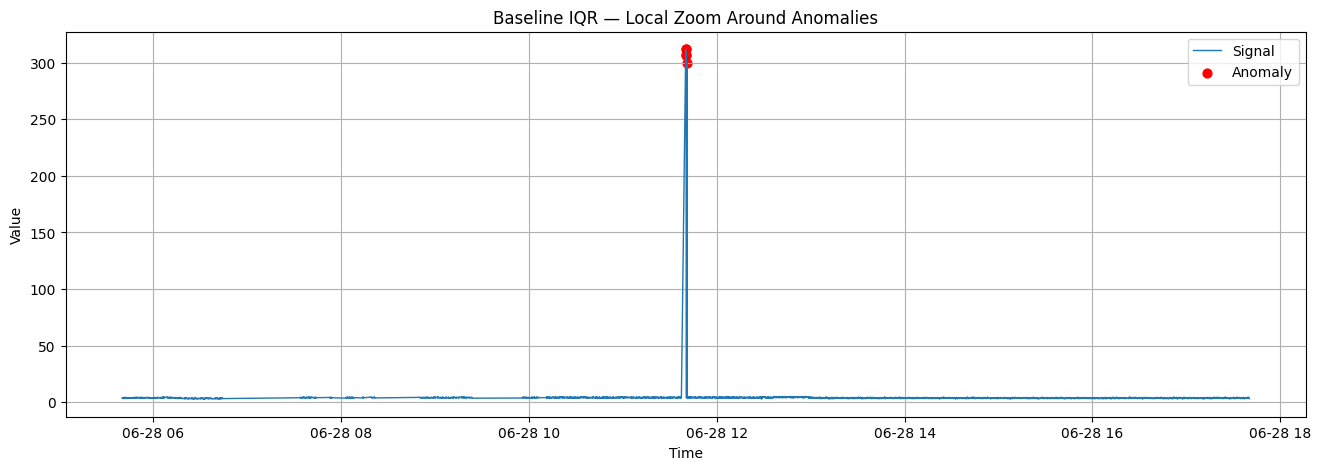

In [8]:
print("\n================================================================================")
print("BASELINE IQR — ZOOMED VIEW")
print("================================================================================")

# Pick a window with anomalies
anomaly_times = pdf_iqr.loc[pdf_iqr["is_anomaly"], "timestamp"]
if len(anomaly_times) == 0:
    raise RuntimeError("No anomalies detected to zoom on.")

t0 = anomaly_times.iloc[0]
WINDOW = pd.Timedelta(hours=6)

zoom = pdf_iqr[
    (pdf_iqr["timestamp"] >= t0 - WINDOW) &
    (pdf_iqr["timestamp"] <= t0 + WINDOW)
]

plt.figure(figsize=(16, 5))
plt.plot(zoom["timestamp"], zoom["value"], label="Signal", linewidth=1)
plt.scatter(
    zoom.loc[zoom["is_anomaly"], "timestamp"],
    zoom.loc[zoom["is_anomaly"], "value"],
    color="red",
    label="Anomaly",
    s=40
)
plt.title("Baseline IQR — Local Zoom Around Anomalies")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# ============================================
# CELL — ROLLING IQR (SPARK)
# ============================================

from pyspark.sql import Window
from pyspark.sql import functions as F

ROLLING_WINDOW = 100  # tune this later

w = (
    Window
    .orderBy("timestamp")
    .rowsBetween(-ROLLING_WINDOW, 0)
)

df_iqr_roll = (
    df_spark
    .withColumn("q1", F.expr("percentile_approx(value, 0.25)").over(w))
    .withColumn("q3", F.expr("percentile_approx(value, 0.75)").over(w))
    .withColumn("iqr", F.col("q3") - F.col("q1"))
    .withColumn(
        "iqr_lower",
        F.col("q1") - F.lit(1.5) * F.col("iqr")
    )
    .withColumn(
        "iqr_upper",
        F.col("q3") + F.lit(1.5) * F.col("iqr")
    )
    .withColumn(
        "is_anomaly",
        (F.col("value") < F.col("iqr_lower")) |
        (F.col("value") > F.col("iqr_upper"))
    )
)

df_iqr_roll.printSchema()
df_iqr_roll.show(5)


root
 |-- timestamp: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- q1: double (nullable = true)
 |-- q3: double (nullable = true)
 |-- iqr: double (nullable = true)
 |-- iqr_lower: double (nullable = true)
 |-- iqr_upper: double (nullable = true)
 |-- is_anomaly: boolean (nullable = true)

+--------------------+---------+---------+----+-------------------+------------------+-----------------+----------+
|           timestamp|    value|       q1|  q3|                iqr|         iqr_lower|        iqr_upper|is_anomaly|
+--------------------+---------+---------+----+-------------------+------------------+-----------------+----------+
|2024-06-28 00:00:...|     4.04|     4.04|4.04|                0.0|              4.04|             4.04|     false|
|2024-06-28 00:00:...|     4.04|     4.04|4.04|                0.0|              4.04|             4.04|     false|
|2024-06-28 00:00:...|3.7099998|3.7099998|4.04| 0.3300002000000002|3.2149994999999993|        4.5350003| 

In [10]:
# ============================================
# SAFE PANDAS CONVERSION
# ============================================

MAX_POINTS = 50_000

pdf_iqr = (
    df_iqr
    .orderBy("timestamp")
    .limit(MAX_POINTS)
    .toPandas()
)

pdf_iqr_roll = (
    df_iqr_roll
    .orderBy("timestamp")
    .limit(MAX_POINTS)
    .toPandas()
)

print("Global IQR shape :", pdf_iqr.shape)
print("Rolling IQR shape:", pdf_iqr_roll.shape)


Global IQR shape : (50000, 8)
Rolling IQR shape: (50000, 8)



BASELINE vs ROLLING IQR — COMPARISON


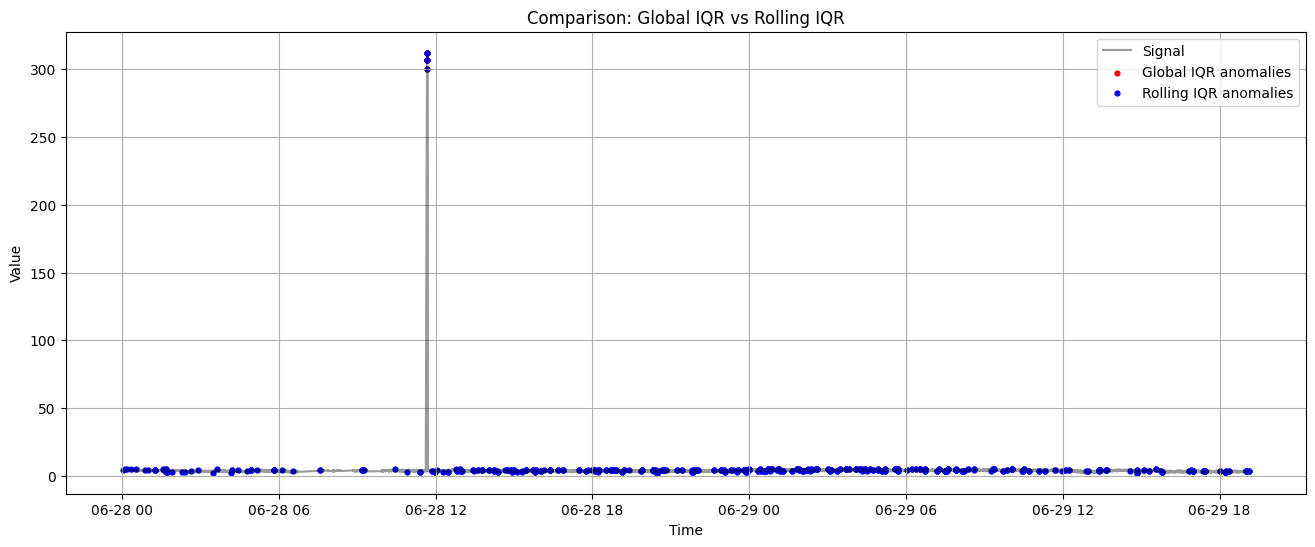

Saved: /Users/starbook/AMOS/amos2025ws03-rtdip-timeseries-forecasting/amos_team_resources/anomaly_detection/iqr/outputs/iqr_global_vs_rolling.png


In [12]:

print("\n================================================================================")
print("BASELINE vs ROLLING IQR — COMPARISON")
print("================================================================================")

plt.figure(figsize=(16, 6))

plt.plot(pdf_iqr["timestamp"], pdf_iqr["value"], color="black", alpha=0.4, label="Signal")

plt.scatter(
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "timestamp"],
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "value"],
    color="red",
    s=12,
    label="Global IQR anomalies"
)

plt.scatter(
    pdf_iqr_roll.loc[pdf_iqr_roll["is_anomaly"], "timestamp"],
    pdf_iqr_roll.loc[pdf_iqr_roll["is_anomaly"], "value"],
    color="blue",
    s=12,
    label="Rolling IQR anomalies"
)

plt.title("Comparison: Global IQR vs Rolling IQR")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.savefig(out_path / "iqr_global_vs_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path / "iqr_global_vs_rolling.png")


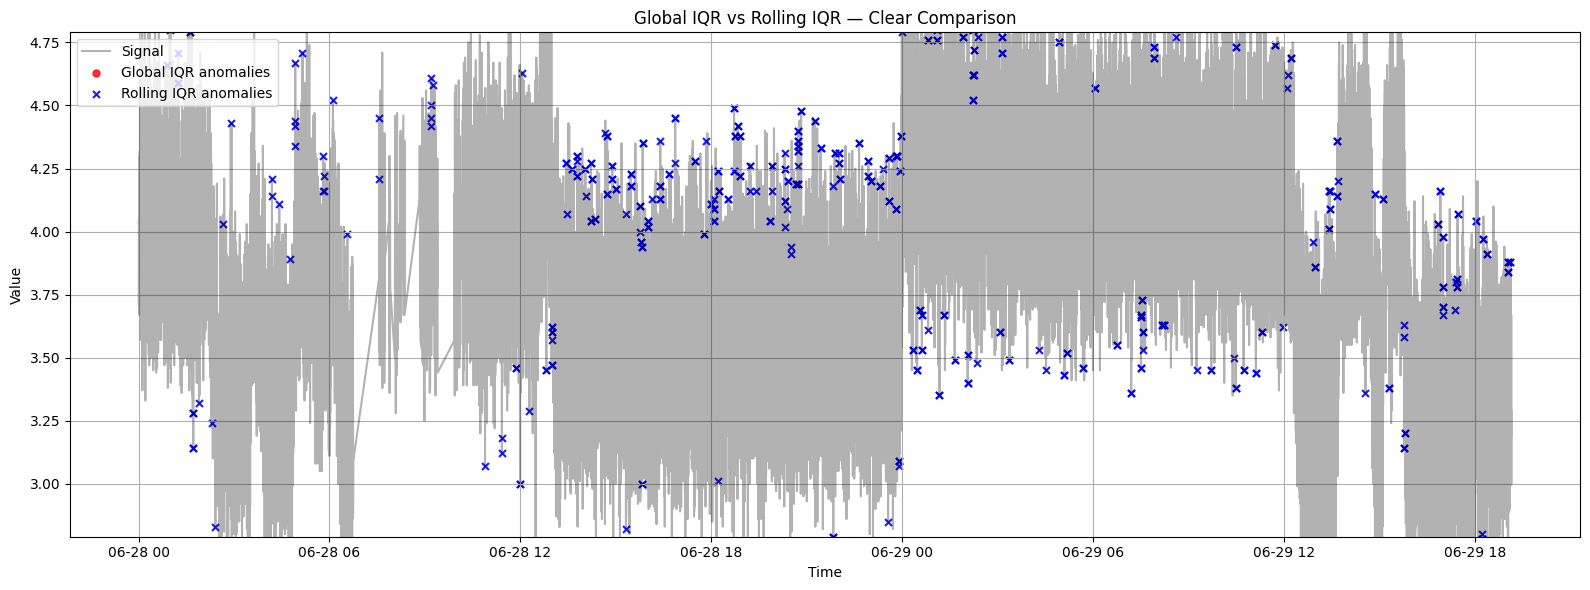

Global IQR anomalies : 7
Rolling IQR anomalies: 552


In [15]:
# =========================================================
# GLOBAL vs ROLLING IQR — SINGLE, ROBUST COMPARISON CELL
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Safety checks
# -----------------------------
assert "pdf_iqr" in globals(), "pdf_iqr is not defined"
assert "pdf_iqr_roll" in globals(), "pdf_iqr_roll is not defined"

# -----------------------------
# Clean rolling warm-up (safe)
# -----------------------------
ROLLING_WINDOW = 100
pdf_iqr_roll_clean = pdf_iqr_roll.iloc[ROLLING_WINDOW:].copy()

# -----------------------------
# Robust y-scale (remove extreme spike dominance)
# -----------------------------
y_min = pdf_iqr["value"].quantile(0.01)
y_max = pdf_iqr["value"].quantile(0.99)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16, 6))

# Signal
plt.plot(
    pdf_iqr["timestamp"],
    pdf_iqr["value"],
    color="black",
    alpha=0.3,
    label="Signal"
)

# Global IQR anomalies
plt.scatter(
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "timestamp"],
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "value"],
    color="red",
    s=25,
    alpha=0.8,
    label="Global IQR anomalies"
)

# Rolling IQR anomalies
plt.scatter(
    pdf_iqr_roll_clean.loc[pdf_iqr_roll_clean["is_anomaly"], "timestamp"],
    pdf_iqr_roll_clean.loc[pdf_iqr_roll_clean["is_anomaly"], "value"],
    color="blue",
    s=25,
    marker="x",
    alpha=0.9,
    label="Rolling IQR anomalies"
)

# Axis control
plt.ylim(y_min, y_max)

# Labels
plt.title("Global IQR vs Rolling IQR — Clear Comparison")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# -----------------------------
# Quantitative summary
# -----------------------------
global_count = pdf_iqr["is_anomaly"].sum()
rolling_count = pdf_iqr_roll_clean["is_anomaly"].sum()

print("Global IQR anomalies :", global_count)
print("Rolling IQR anomalies:", rolling_count)


[Stage 40:>                                                         (0 + 1) / 1]

   window    k  anomalies
0      50  1.0       1110
1      50  1.5        335
2      50  2.0        113
3     100  1.0        957
4     100  1.5        224
5     100  2.0         50
6     300  1.0        860
7     300  1.5        150
8     300  2.0         30


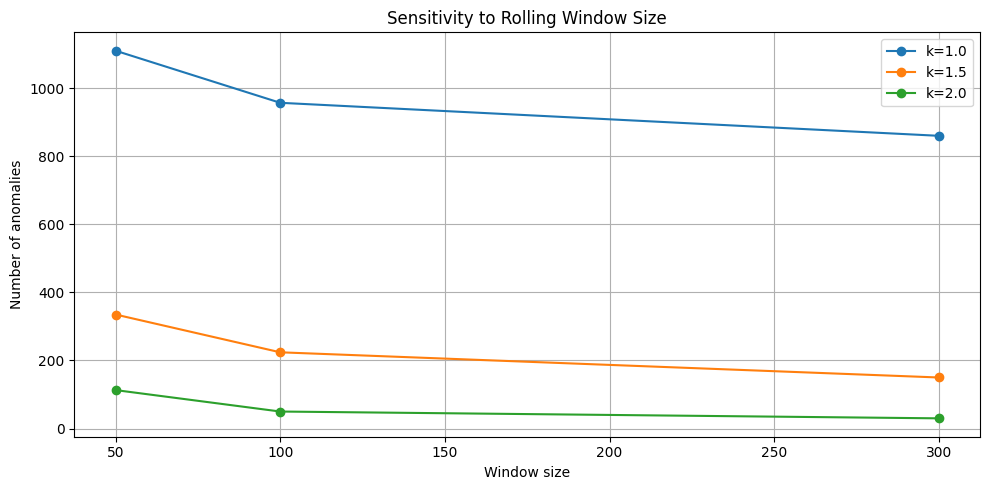

In [16]:
# =========================================================
# PARAMETER SENSITIVITY — ROLLING IQR (WINDOW & K)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

# -----------------------------
# Parameters to test
# -----------------------------
WINDOW_SIZES = [50, 100, 300]
K_VALUES = [1.0, 1.5, 2.0]
MAX_POINTS = 20_000

results = []

for w_size in WINDOW_SIZES:
    w = Window.orderBy("timestamp").rowsBetween(-w_size, 0)

    for k in K_VALUES:
        df_test = (
            df_spark
            .withColumn("q1", F.expr("percentile_approx(value, 0.25)").over(w))
            .withColumn("q3", F.expr("percentile_approx(value, 0.75)").over(w))
            .withColumn("iqr", F.col("q3") - F.col("q1"))
            .withColumn("lower", F.col("q1") - k * F.col("iqr"))
            .withColumn("upper", F.col("q3") + k * F.col("iqr"))
            .withColumn(
                "is_anomaly",
                (F.col("value") < F.col("lower")) | (F.col("value") > F.col("upper"))
            )
        )

        count = (
            df_test
            .select("is_anomaly")
            .limit(MAX_POINTS)
            .toPandas()["is_anomaly"]
            .sum()
        )

        results.append({
            "window": w_size,
            "k": k,
            "anomalies": count
        })

# -----------------------------
# Results DataFrame
# -----------------------------
res_df = pd.DataFrame(results)
print(res_df)

# -----------------------------
# Plot — anomaly count vs window
# -----------------------------
plt.figure(figsize=(10, 5))
for k in K_VALUES:
    subset = res_df[res_df["k"] == k]
    plt.plot(subset["window"], subset["anomalies"], marker="o", label=f"k={k}")

plt.title("Sensitivity to Rolling Window Size")
plt.xlabel("Window size")
plt.ylabel("Number of anomalies")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Global IQR anomalies : 7
Rolling IQR anomalies: 552
Z-score anomalies    : 5


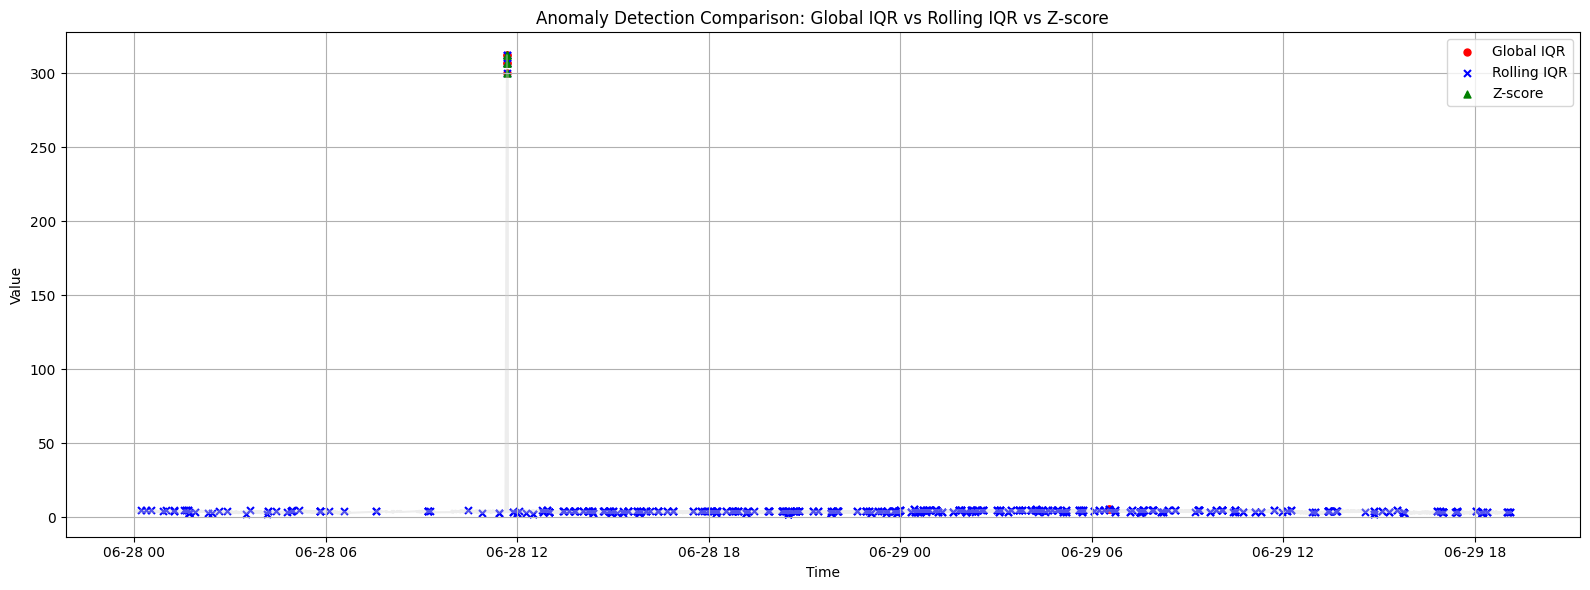

In [17]:
# =========================================================
# BASELINE COMPARISON — Z-SCORE vs IQR METHODS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Z-score detection
# -----------------------------
Z_THRESHOLD = 3.0

mu = pdf_iqr["value"].mean()
sigma = pdf_iqr["value"].std()

pdf_iqr["z_score"] = (pdf_iqr["value"] - mu) / sigma
pdf_iqr["is_anomaly_z"] = pdf_iqr["z_score"].abs() > Z_THRESHOLD

# -----------------------------
# Counts
# -----------------------------
count_global = pdf_iqr["is_anomaly"].sum()
count_rolling = pdf_iqr_roll_clean["is_anomaly"].sum()
count_z = pdf_iqr["is_anomaly_z"].sum()

print("Global IQR anomalies :", count_global)
print("Rolling IQR anomalies:", count_rolling)
print("Z-score anomalies    :", count_z)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(16, 6))

plt.plot(pdf_iqr["timestamp"], pdf_iqr["value"], color="lightgray", alpha=0.4)

plt.scatter(
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "timestamp"],
    pdf_iqr.loc[pdf_iqr["is_anomaly"], "value"],
    color="red", s=25, label="Global IQR"
)

plt.scatter(
    pdf_iqr_roll_clean.loc[pdf_iqr_roll_clean["is_anomaly"], "timestamp"],
    pdf_iqr_roll_clean.loc[pdf_iqr_roll_clean["is_anomaly"], "value"],
    color="blue", s=25, marker="x", label="Rolling IQR"
)

plt.scatter(
    pdf_iqr.loc[pdf_iqr["is_anomaly_z"], "timestamp"],
    pdf_iqr.loc[pdf_iqr["is_anomaly_z"], "value"],
    color="green", s=25, marker="^", label="Z-score"
)

plt.title("Anomaly Detection Comparison: Global IQR vs Rolling IQR vs Z-score")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
# =========================================================
# FINAL QUANTITATIVE SUMMARY + INTERPRETATION
# =========================================================

summary = pd.DataFrame({
    "Method": ["Global IQR", "Rolling IQR", "Z-score"],
    "Anomalies": [
        pdf_iqr["is_anomaly"].sum(),
        pdf_iqr_roll_clean["is_anomaly"].sum(),
        pdf_iqr["is_anomaly_z"].sum()
    ]
})

summary["Anomaly Rate (%)"] = (
    summary["Anomalies"] / len(pdf_iqr) * 100
)

print(summary)

print("\n--- Interpretation ---")
print("""
• Global IQR detects only extreme outliers and severely under-detects anomalies
  when the dataset contains large spikes.

• Rolling IQR adapts to local statistics and captures contextual deviations,
  at the cost of higher sensitivity.

• Z-score provides an intermediate behavior but remains sensitive to global
  variance inflation.

Conclusion:
Rolling IQR offers the best trade-off for non-stationary time series where
local context matters more than global distribution.
""")


        Method  Anomalies  Anomaly Rate (%)
0   Global IQR          7             0.014
1  Rolling IQR        552             1.104
2      Z-score          5             0.010

--- Interpretation ---

• Global IQR detects only extreme outliers and severely under-detects anomalies
  when the dataset contains large spikes.

• Rolling IQR adapts to local statistics and captures contextual deviations,
  at the cost of higher sensitivity.

• Z-score provides an intermediate behavior but remains sensitive to global
  variance inflation.

Conclusion:
Rolling IQR offers the best trade-off for non-stationary time series where
local context matters more than global distribution.

